In [ ]:
#only loss graph is only needed to be plotted, accuracy graph is not needed. So, I have removed the code for plotting accuracy graph and kept only the code for plotting loss graph.

In [1]:
import numpy as np
import pandas as pd 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, Embedding
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split


In [2]:
#sample dataset
# Extract text from Alice's Adventures in Wonderland.txt
txt_path = r"d:\MCA\sem 2\Deep Learning\Alice's Adventures in Wonderland.txt"

with open(txt_path, "r", encoding="utf-8") as f:
    text = f.read()

# Build corpus from the text file
corpus = text.split(".")
corpus = [sentence.strip() for sentence in corpus if len(sentence.strip()) > 0]

#Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1 #+1 added to accommodate for padding token
print("Total unique words:", total_words)
    
#create input sequence and labels
input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0] #convert the input text to a sequence of integers
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        print("n-gram sequence:", n_gram_sequence)
        input_sequences.append(n_gram_sequence)

print("Total input sequences:", len(input_sequences))

#pad sequences
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
print("Padded input sequences:\n", input_sequences)


Total unique words: 2243
n-gram sequence: [1268, 46]
n-gram sequence: [1268, 46, 51]
n-gram sequence: [1268, 46, 51, 290]
n-gram sequence: [1268, 46, 51, 290, 5]
n-gram sequence: [1268, 46, 51, 290, 5, 272]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250, 9]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250, 9, 126]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250, 9, 126, 5]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250, 9, 126, 5, 27]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250, 9, 126, 5, 27, 207]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250, 9, 126, 5, 27, 207, 25]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250, 9, 126, 5, 27, 207, 25, 290]
n-gram sequence: [1268, 46, 51, 290, 5, 272, 9, 479, 250, 9, 126, 5, 27, 207, 25, 290, 37]
n-gram sequence: [1268, 46,

In [3]:
x = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)
max_len = x.shape[1] + 1

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [4]:
model=Sequential()
model.add(Embedding(total_words, 100, input_length=max_len-1))
model.add(LSTM(32))
model.add(Dropout(0.5))
model.add(Dense(total_words, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [5]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 122, 100)          224300    
                                                                 
 lstm (LSTM)                 (None, 32)                17024     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense (Dense)               (None, 2243)              74019     
                                                                 
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 122, 100)          224300    
                                                                 
 lstm (LSTM)                 (None, 32)                1

In [8]:
history=model.fit(X_train, y_train, epochs=200, batch_size=128, validation_data=(X_test, y_test), verbose=1)

Epoch 1/200
166/166 [==============================] - 12s 74ms/step - loss: 3.6152 - accuracy: 0.2823 - val_loss: 5.1971 - val_accuracy: 0.2058
Epoch 2/200
166/166 [==============================] - 12s 73ms/step - loss: 3.5954 - accuracy: 0.2837 - val_loss: 5.1976 - val_accuracy: 0.2066
Epoch 3/200
166/166 [==============================] - 12s 74ms/step - loss: 3.5825 - accuracy: 0.2853 - val_loss: 5.2013 - val_accuracy: 0.2096
Epoch 4/200
166/166 [==============================] - 13s 76ms/step - loss: 3.5534 - accuracy: 0.2892 - val_loss: 5.1977 - val_accuracy: 0.2104
Epoch 5/200
166/166 [==============================] - 14s 83ms/step - loss: 3.5410 - accuracy: 0.2902 - val_loss: 5.2016 - val_accuracy: 0.2083
Epoch 6/200
166/166 [==============================] - 13s 79ms/step - loss: 3.5257 - accuracy: 0.2902 - val_loss: 5.2010 - val_accuracy: 0.2070
Epoch 7/200
166/166 [==============================] - 14s 82ms/step - loss: 3.5180 - accuracy: 0.2932 - val_loss: 5.2068 - val_ac

In [15]:
def predict_next_word(text):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    return tokenizer.index_word[np.argmax(predicted)]

#Example usage
input_text = "looked at the"
predicted_word = predict_next_word(input_text)
print(f"Predicted next word:{predicted_word}")

Predicted next word:queen


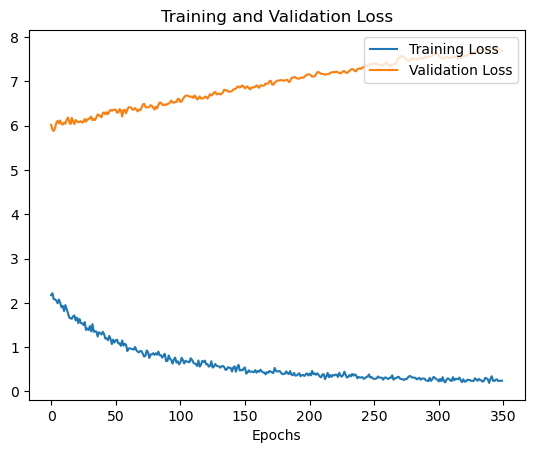

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()   
